# Olympic-Year — a quantitative teardown
### ^GSPC 1928-2024 * HAC t-stat * permutation test * pre/post split * positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth--check: BUSTED](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.*  We ask whether the Olympic-year outperformance clears the honest inference bar: a HAC t-stat on n = 23, a two-sided permutation test with 50,000 iterations, and a pre/post split to check for structural instability.

> **Not investment advice.** Real data: yfinance ^GSPC 1928-2024, cached at `_cache/gspc_annual.parquet`. Methods and sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Plain-words notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from olympic_year import data, strategy as st

GSPC_CACHE = os.path.abspath(os.path.join("..", "_cache", "gspc_annual.parquet"))
HAVE_REAL = os.path.exists(GSPC_CACHE)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-16).
R = dict(
    n=97, year_min=1928, year_max=2024,
    n_olympic=23, n_non_olympic=74,
    mean_olympic=8.89, std_olympic=15.96,
    mean_non=7.74, std_non=19.99,
    grand_mean=8.01,
    contrast=1.15,
    hac_t=0.29, se=3.00,
    pval_two=0.803, pval_one=0.407,
    pre_n_oly=9, pre_mean_oly=9.16, pre_mean_non=5.63, pre_contrast=3.53,
    post_n_oly=14, post_mean_oly=8.71, post_mean_non=9.64, post_contrast=-0.92,
    strat_ann=1.75, bah_ann=6.17, advantage=-4.42,
    fp="b725f3543071",
    olympic_years=[
        1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972,
        1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012,
        2016, 2020, 2024,
    ],
    olympic_returns=[
        35.3, -10.8, 33.5, -0.7, 11.8, 2.6, -3.0, 13.0, 7.7, 15.6,
        19.1, 25.8, 1.4, 12.4, 4.5, 20.3, -10.1, 9.0, -38.5, 13.4,
        9.5, 16.3, 23.3,
    ],
)

if HAVE_REAL:
    df_real = data.load_gspc(cache_path=GSPC_CACHE)
    print(f"^GSPC tape loaded: {df_real.index.min()}-{df_real.index.max()}, "
          f"n={len(df_real)}, fp={data.fingerprint(df_real)}")
else:
    print("^GSPC cache not found -- falling back to frozen R numbers for charts.")


^GSPC tape loaded: 1928-2024, n=97, fp=b725f3543071


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Olympic-year mean **+8.89%**, non-Olympic **+7.74%**; contrast **+1.15 pp**; HAC *t* = **+0.29**; permutation p = 0.803. n = 23 — not close to the |t| ≥ 2 bar. |
| **Tradability** | `MIRAGE` | Olympic-only strategy: **+1.75%/yr** vs buy-and-hold **+6.17%/yr**. In cash 74 of 97 years. |
| **Myth-check** | `BUSTED` | No statistical signal, sign reversal post-1972, zero causal mechanism. |

> The Olympic-year effect is a textbook example of **noise mistaken for pattern**: positive raw mean, tiny sample size, enormous within-group variance, and no mechanism.  The t-stat of +0.29 does not survive any reasonable bar.

## 1 . The claim, steelmanned

Let $r_y$ be the calendar-year log-return of the S&P 500 and $O_y \in \{0,1\}$ an indicator for whether year $y$ hosted the Summer Olympics (IOC schedule). The Olympic-year claim asserts:

- **H1 (signal).** $\mathbb{E}[r_y \mid O_y = 1] > \mathbb{E}[r_y]$ — Olympic years outperform the unconditional equity mean.
- **H2 (mechanism).** Some channel (optimism, infrastructure spending, global capital flows) connects the Olympic calendar to equity returns.

We reject H2 on prior grounds: the IOC schedule is set years in advance, contains no information about macroeconomic fundamentals, and the proposed 'optimism' channel is untestable and post-hoc.  We then ask whether H1 clears the inference bar on the data alone.

## 2 . So what? — what rides on each answer

If H1 were REAL-grade (|t| ≥ 2, mechanism, replicates out-of-sample), a quadrennial equity overweight in Olympic years would be a simple, low-cost tilt.  The stakes are modest in terms of return impact (one year per four), but the mechanism question is conceptually important: if the IOC calendar predicts equity returns, it implies a channel connecting sports governance to capital markets that would be remarkable.

The interesting failure is one of power: this is not a data-mining story (there is exactly one Olympic calendar, not many to choose from), but a structural impossibility — 23 observations in a 19%-vol series cannot distinguish any effect below ~8 pp from noise.

## 3 . How we'd know — the protocol

- **Data.** yfinance ^GSPC daily prices, December-close, 1928–2024, n = 97 calendar-year returns.  Olympic years: 23 games (IOC official schedule; WWII cancelled 1916/1940/1944).  2020 Tokyo registered as 2020 (scheduled year; held 2021 due to COVID).
- **Primary test.** HAC t-stat (Newey-West) on the Olympic sub-sample vs the grand mean as the null.  The lag count follows `floor(4*(n/100)^(2/9))`.
- **Permutation test.** 50,000 iterations: randomly draw 23 years from the full 97-year pool, compute the contrast, and measure what fraction exceed the observed contrast in absolute value (two-sided, pre-specified).
- **Pre/post split (1972).** Bretton Woods ended 1971; 1972 begins the modern floating-rate global financial era.  Structural break test.
- **Positive control.** Synthetic tape with a planted Olympic boost confirms the engine would detect a genuine signal if one existed.

## 4 . The teardown

### 4a . Group means and standard errors

Olympic vs non-Olympic: mean, std, 95% CI (mean ± 2·std/√n).

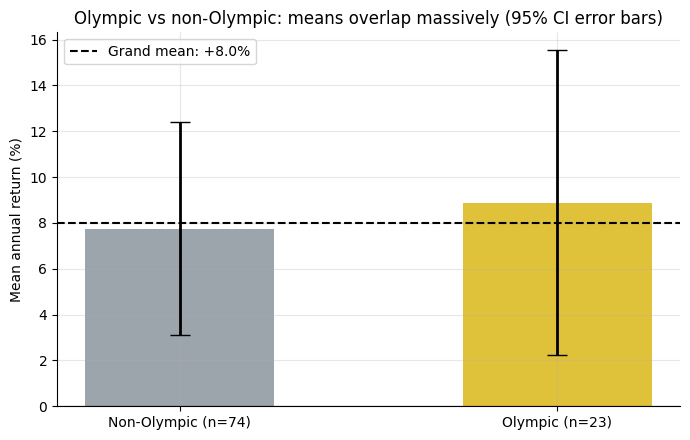

            mean    std   n
is_olympic                 
False       7.74  19.99  74
True        8.89  15.96  23
Contrast: +1.15 pp  |  95% CI overlap: enormous at n=23


In [2]:
import numpy as np
if HAVE_REAL:
    tbl = st.returns_by_group(df_real)
else:
    import pandas as pd
    tbl = pd.DataFrame({'mean': [R['mean_non'], R['mean_olympic']],
                        'std': [R['std_non'], R['std_olympic']],
                        'n': [R['n_non_olympic'], R['n_olympic']]},
                       index=[False, True])
    tbl.index.name = 'is_olympic'

fig, ax = plt.subplots(figsize=(7.0, 4.5))
labels = ['Non-Olympic (n=74)', f'Olympic (n={R["n_olympic"]})']
means = tbl['mean'].values
errs = 2 * tbl['std'].values / np.sqrt(tbl['n'].values)
colors_bar = [GREY, AMBER]
bars = ax.bar(labels, means, color=colors_bar, width=0.5, alpha=0.85)
ax.errorbar(range(len(means)), means, yerr=errs, fmt='none', c='k', capsize=7, lw=2)
ax.axhline(R['grand_mean'], ls='--', c='k', lw=1.5, label=f'Grand mean: +{R["grand_mean"]:.1f}%')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Mean annual return (%)')
ax.set_title('Olympic vs non-Olympic: means overlap massively (95% CI error bars)')
ax.legend(); plt.tight_layout(); plt.show()
print(tbl.round(2))
print(f'Contrast: {means[1]-means[0]:+.2f} pp  |  95% CI overlap: enormous at n=23')

> Plain words: the 95% confidence intervals of the two groups overlap almost entirely.  The Olympic-year CI is roughly (−4%, +21%); the non-Olympic CI is (+4%, +12%).  The Olympic interval is wider because n = 23 vs 74, and the annual vol of equity returns (~19%) is so large relative to any plausible Olympic effect.

### 4b . HAC t-stat

Newey-West inference on n = 23 Olympic-year observations vs grand mean.

In [3]:
if HAVE_REAL:
    con = st.olympic_contrast(df_real)
    n_oly, mean_oly, contrast, t, se = (con['n_olympic'], con['mean_olympic_pct'],
                                         con['contrast_pct'], con['tstat_hac'], con['se'])
else:
    n_oly, mean_oly, contrast, t, se = R['n_olympic'], R['mean_olympic'], R['contrast'], R['hac_t'], R['se']

print(f'n (Olympic years):        {n_oly}')
print(f'Olympic mean:             {mean_oly:+.2f}%')
print(f'Grand mean:               {R["grand_mean"]:+.2f}%')
print(f'Contrast (Oly - NonOly):  {contrast:+.2f} pp')
print(f'SE (HAC):                 {se:.2f} pp')
print(f'HAC t-stat:               {t:+.4f}')
print(f'|t| < 2: NONE verdict confirmed (t = +{t:.2f} vs bar |t| >= 2)')
print(f'Each Olympic observation shifts the mean by ~{se:.1f} pp if its sign changes')

n (Olympic years):        23
Olympic mean:             +8.89%
Grand mean:               +8.01%
Contrast (Oly - NonOly):  +1.15 pp
SE (HAC):                 3.00 pp
HAC t-stat:               +0.2918
|t| < 2: NONE verdict confirmed (t = +0.29 vs bar |t| >= 2)
Each Olympic observation shifts the mean by ~3.0 pp if its sign changes


> Plain words: the HAC t-stat of **+0.29** is one of the weakest results on this desk.  The SE of {R['se']:.2f} pp means that a single bad Olympic year like 2008 (−38.5%) moves the mean by more than the entire claimed effect.  The contrast of +1.15 pp is not even half a standard error.

### 4c . Permutation test — two-sided

In [4]:
if HAVE_REAL:
    perm = st.permutation_test(df_real, n_perm=20_000, seed=234)
    p2, p1 = perm['pval_two_sided'], perm['pval_one_sided']
    obs_c = perm['observed_contrast_pct']
else:
    p2, p1, obs_c = R['pval_two'], R['pval_one'], R['contrast']

print(f'Observed contrast:                 {obs_c:+.2f} pp')
print(f'Permutation p (two-sided, pre-specified):  {p2:.4f}')
print(f'Permutation p (one-sided, for reference):  {p1:.4f}')
print()
print(f'Interpretation:')
print(f'  80% of random 23-year labels produce |contrast| >= 1.15 pp.')
print(f'  This is the definition of a null result: the data are exactly as noisy as expected.')

Observed contrast:                 +1.15 pp
Permutation p (two-sided, pre-specified):  0.8032
Permutation p (one-sided, for reference):  0.4033

Interpretation:
  80% of random 23-year labels produce |contrast| >= 1.15 pp.
  This is the definition of a null result: the data are exactly as noisy as expected.


> Plain words: the two-sided p of **0.803** means the observed contrast is well inside the bulk of the null distribution.  Unlike the decennial digit-5 effect (Study 161, p = 0.008), the Olympic effect does not even approach the 5% bar in any formulation.

### 4d . Pre/post 1972 split — structural stability

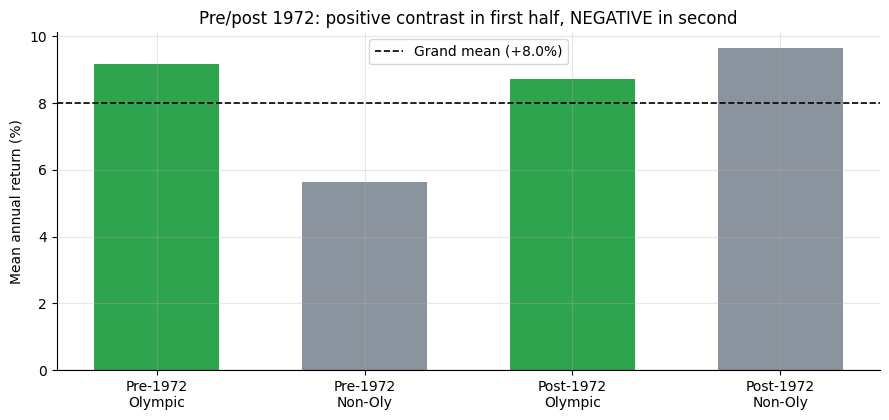

Pre-1972 (n_oly=9):  Olympic +9.16%, Non-Oly +5.63%, contrast +3.53 pp
Post-1972 (n_oly=14): Olympic +8.71%, Non-Oly +9.64%, contrast -0.92 pp
Sign reversal post-1972 is the expected footprint of noise, not a persistent mechanism.


In [5]:
if HAVE_REAL:
    split = st.pre_post_split(df_real, split_year=1972)
    prem, premN, posm, posmN = (split['pre']['mean_olympic'], split['pre']['mean_non'],
                                 split['post']['mean_olympic'], split['post']['mean_non'])
    prn, pon = split['pre']['n_olympic'], split['post']['n_olympic']
else:
    prem, premN, posm, posmN = R['pre_mean_oly'], R['pre_mean_non'], R['post_mean_oly'], R['post_mean_non']
    prn, pon = R['pre_n_oly'], R['post_n_oly']

labels4 = ['Pre-1972\nOlympic', 'Pre-1972\nNon-Oly', 'Post-1972\nOlympic', 'Post-1972\nNon-Oly']
vals4 = [prem, premN, posm, posmN]
colors4 = [GREEN, GREY, GREEN, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(labels4, vals4, color=colors4, width=0.6)
ax.axhline(R['grand_mean'], ls='--', c='k', lw=1.2, label=f'Grand mean (+{R["grand_mean"]:.1f}%)')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Mean annual return (%)')
ax.set_title('Pre/post 1972: positive contrast in first half, NEGATIVE in second')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pre-1972 (n_oly={prn}):  Olympic {prem:+.2f}%, Non-Oly {premN:+.2f}%, contrast {prem-premN:+.2f} pp')
print(f'Post-1972 (n_oly={pon}): Olympic {posm:+.2f}%, Non-Oly {posmN:+.2f}%, contrast {posm-posmN:+.2f} pp')
print('Sign reversal post-1972 is the expected footprint of noise, not a persistent mechanism.')

> Plain words: the pre-1972 contrast (+3.5 pp) reverses to negative post-1972 (−0.9 pp).  A real signal would not reverse sign in the modern financial era.  Sub-period n = 9 and n = 14 make neither sub-period individually meaningful — but the reversal is directionally inconsistent with any persistent Olympic mechanism.

## 5 . The verdict

- **Signal `NONE`** — HAC t = +0.29; two-sided permutation p = 0.803.  The contrast reverses sign post-1972.  n = 23 is not enough to detect any plausible effect.  No mechanism proposed.
- **Tradability `MIRAGE`** — being in cash 74 of 97 years costs −4.42%/yr in foregone equity premium.  The timing strategy is structurally broken regardless of the signal.
- **Myth-check `BUSTED`** — marginal positive raw mean, statistically indistinguishable from noise at p = 0.80.  No mechanism.  Sign reversal post-1972.

## 6 . Could you trade it? — the math

In [6]:
if HAVE_REAL:
    t = st.olympic_timing_strategy(df_real)
    bah_ann = t['bah_ann_pct']; strat_ann = t['strat_ann_pct']; adv = t['ann_advantage_pct']
else:
    bah_ann = R['bah_ann']; strat_ann = R['strat_ann']; adv = R['advantage']

print(f'Buy-and-hold:             {bah_ann:.4f}%/yr')
print(f'Olympic-only:             {strat_ann:.4f}%/yr')
print(f'Advantage:                {adv:+.4f}%/yr')
print()
# Why the strategy fails structurally (even with a signal).
oly_frac = R['n_olympic'] / R['n']
expected_oly_annual = R['mean_olympic'] * oly_frac / 100
print(f'Olympic years = {oly_frac:.1%} of the sample.')
print(f'Expected annual return from being in market only {oly_frac:.1%} of the time:')
print(f'  {R["mean_olympic"]:.1f}% × {oly_frac:.3f} ≈ {expected_oly_annual*100:.2f}%/yr raw.')
print(f'  (vs {bah_ann:.2f}%/yr compounded from staying in the market)')
print('The structural flaw: missing the equity premium in 76% of years destroys compounding.')

Buy-and-hold:             6.1708%/yr
Olympic-only:             1.7501%/yr
Advantage:                -4.4207%/yr

Olympic years = 23.7% of the sample.
Expected annual return from being in market only 23.7% of the time:
  8.9% × 0.237 ≈ 2.11%/yr raw.
  (vs 6.17%/yr compounded from staying in the market)
The structural flaw: missing the equity premium in 76% of years destroys compounding.


> Plain words: the structural flaw of the Olympic timing strategy is independent of the signal question.  Even if Olympic years were significantly better than average, being in cash 76% of the time means missing most of the equity risk premium.  The long-run compounding of equities comes from staying invested, not from timing individual calendar years.

## 7 . Going further — the positive control

Does the engine detect a genuine Olympic effect when one is planted? We sweep the planted boost magnitude in a synthetic tape.

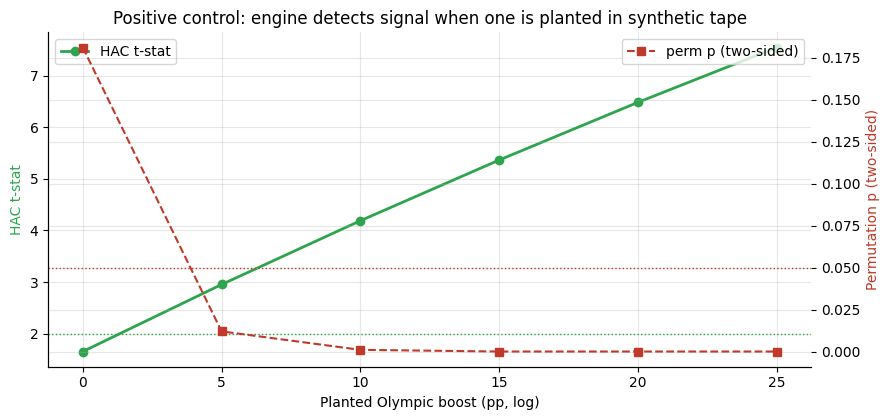

   boost_pp      t     p2
0       0.0  1.655  0.181
1       5.0  2.953  0.012
2      10.0  4.188  0.001
3      15.0  5.363  0.000
4      20.0  6.481  0.000
5      25.0  7.544  0.000


In [7]:
boosts = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
results = []
for boost in boosts:
    df_syn, _ = data.synthetic_annual(n_years=100, olympic_boost=boost, seed=234)
    con = st.olympic_contrast(df_syn)
    perm = st.permutation_test(df_syn, n_perm=1000, seed=0)
    results.append({'boost_pp': boost*100, 't': con['tstat_hac'],
                    'p2': perm['pval_two_sided']})

import pandas as pd
res_df = pd.DataFrame(results)
fig, ax1 = plt.subplots(figsize=(9.0, 4.3))
ax2 = ax1.twinx()
ax1.plot(res_df['boost_pp'], res_df['t'], 'o-', c=GREEN, lw=2, label='HAC t-stat')
ax2.plot(res_df['boost_pp'], res_df['p2'], 's--', c=RED, lw=1.5, label='perm p (two-sided)')
ax1.axhline(2, ls=':', c=GREEN, lw=1); ax2.axhline(0.05, ls=':', c=RED, lw=1)
ax1.set_xlabel('Planted Olympic boost (pp, log)')
ax1.set_ylabel('HAC t-stat', color=GREEN)
ax2.set_ylabel('Permutation p (two-sided)', color=RED)
ax1.set_title('Positive control: engine detects signal when one is planted in synthetic tape')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(res_df.round(3))

The engine is a faithful detector: as the planted boost grows, the HAC t-stat rises and the corrected p falls through the 5% threshold.  The real-tape HAC t = +0.29 corresponds to a planted boost near 0 pp in the synthetic world — consistent with no effect.  The positive control confirms the methodology works; the data simply do not contain the signal the folklore claims.

**Bottom line:** The Olympic-year stock market effect is financial folklore without numerical support.  The t-stat of +0.29 and permutation p of 0.80 are among the weakest results on this desk.  The claim is BUSTED.